In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile

def time_axis(fs, duration):
    T = 1/fs
    t = np.arange(0, duration, T)
    return t

def generate_sine(f, t, A=1, p=0):
    y = A * np.sin(2 * np.pi * f * t + p)
    return y

def spectrum(x, fs, NFFT=-1):
    if NFFT == -1:
        NFFT = len(x)
    X = np.fft.fft(x, NFFT)
    N = len(X)
    X = X[:N//2]
    mag = np.abs(X)*2/N
    freq = np.arange( len(mag) ) * fs / N
    return freq, mag

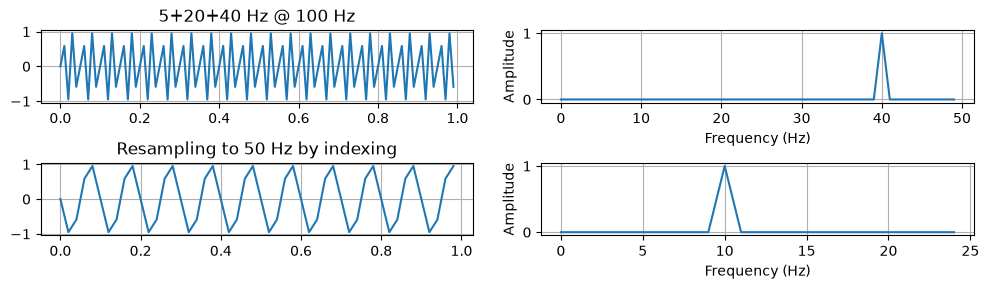

In [2]:
fs = 100
t = time_axis(fs, 1)
x = generate_sine(40, t, 1)

freq, mag = spectrum(x, fs)
plt.figure( figsize=(10, 3) )
plt.subplot(2,2,1)
plt.plot(t, x); plt.grid(); plt.title("5+20+40 Hz @ 100 Hz")
plt.subplot(2,2,2)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")


M = 2
t_new = t[::M]
x_new = x[::M]
freq, mag = spectrum(x_new, fs/M)
plt.subplot(2,2,3)
plt.plot(t_new, x_new); plt.grid(); plt.title("Resampling to 50 Hz by indexing")
plt.subplot(2,2,4)
plt.plot(freq, mag); plt.grid()
plt.xlabel("Frequency (Hz)"); plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()